# StayEase Booking Analytics
## Machine Learning Laboratory Exercise – 1

This notebook investigates the StayEase booking dataset through:
- Dataset understanding
- Data quality assessment
- Data preprocessing
- Customer and booking behaviour
- Business relationships
- Business insights
- Actionable recommendations

All preprocessing decisions are supported by evidence from the dataset.


In [53]:
# Import libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

DATA_PATH = "https://raw.githubusercontent.com/Adarsh-031/Data-Quality-Assessment-and-Exploratory-Data-Analysis-on-StayEase-Booking/main/StayEase_Cleaned_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 102658
Columns: 37


## Investigation 1 — Understand the Dataset

We first inspect the structure, attribute types, important business fields, missing values, duplicates, categorical values, and basic statistics.


In [54]:
# Dataset overview
print("Dataset shape:", df.shape)
print("Arrival years:", sorted(df["arrival_year"].dropna().unique()))

display(df.head())

overview = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Duplicate rows", "Missing-value cells"],
    "Value": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        int(df.isna().sum().sum())
    ]
})

display(overview)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Dataset shape: (102658, 37)
Arrival years: [np.int64(2015), np.int64(2016), np.int64(2017)]


,hotel_type,booking_status,advance_booking_days,arrival_year,arrival_month,arrival_week,arrival_day,weekend_nights,weekday_nights,num_adults,num_children,num_infants,meal_plan,guest_country,booking_segment,booking_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room,assigned_room,modifications,deposit_type,travel_agent_id,corporate_id,waiting_days,customer_category,avg_daily_rate,parking_spaces,special_requests,reservation_status,reservation_date,total_stay_nights,booking_season,family_booking,total_guests,is_long_stay
0,Luxury Resort,1,2,2016,June,24,5,1,0,2,0.0,0,SB,Unknown,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,Not Applicable,0,Regular,109.0,0,1,Cancelled,04-06-2016,1,Summer,0,2.0,0
1,Urban Hotel,1,82,2016,September,38,15,0,3,2,0.0,0,SB,GBR,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,Not Applicable,0,Regular,149.4,0,1,Cancelled,12-09-2016,3,Autumn,0,2.0,0
2,Luxury Resort,0,62,2015,August,34,20,2,8,2,0.0,0,SB,ESP,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,243.0,Not Applicable,0,Regular,104.0,0,0,Checked-Out,30-08-2015,10,Summer,0,2.0,1
3,Urban Hotel,0,133,2016,May,21,17,0,3,2,0.0,0,SB,NLD,Online TA,TA/TO,0,0,0,A,B,1,No Deposit,9.0,Not Applicable,0,Regular-Party,105.3,0,0,Checked-Out,20-05-2016,3,Spring,0,2.0,0
4,Luxury Resort,1,87,2016,August,33,12,1,2,2,1.0,0,SB,BRA,Direct,Direct,0,0,0,A,A,0,No Deposit,250.0,Not Applicable,0,Regular,204.0,0,0,Cancelled,02-06-2016,3,Summer,1,3.0,0


,Metric,Value
0,Rows,102658
1,Columns,37
2,Duplicate rows,13260
3,Missing-value cells,16751



Data types:


,dtype
hotel_type,object
booking_status,int64
advance_booking_days,int64
arrival_year,int64
arrival_month,object
arrival_week,int64
arrival_day,int64
weekend_nights,int64
weekday_nights,int64
num_adults,int64


In [55]:
# Classify attributes by business meaning
categorical_cols = [
    "hotel_type", "meal_plan", "guest_country", "booking_segment",
    "booking_channel", "reserved_room", "assigned_room", "deposit_type",
    "customer_category", "reservation_status", "booking_season"
]

temporal_cols = [
    "arrival_year", "arrival_month", "arrival_week",
    "arrival_day", "reservation_date"
]

binary_cols = [
    "booking_status", "is_repeated_guest",
    "family_booking", "is_long_stay"
]

numeric_cols = [
    "advance_booking_days", "weekend_nights", "weekday_nights",
    "num_adults", "num_children", "num_infants",
    "previous_cancellations", "previous_bookings_not_canceled",
    "modifications", "waiting_days", "parking_spaces",
    "special_requests", "total_stay_nights", "total_guests",
    "avg_daily_rate"
]

identifier_cols = ["travel_agent_id", "corporate_id"]

classification = pd.DataFrame({
    "Attribute type": [
        "Categorical", "Temporal", "Binary / Flag",
        "Numeric", "Identifier"
    ],
    "Count": [
        len(categorical_cols), len(temporal_cols),
        len(binary_cols), len(numeric_cols), len(identifier_cols)
    ]
})

display(classification)


,Attribute type,Count
0,Categorical,11
1,Temporal,5
2,Binary / Flag,4
3,Numeric,15
4,Identifier,2


In [56]:
# Missing values
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

display(
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

# Duplicate records
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count} ({dup_count / len(df) * 100:.2f}%)")


,missing_count,missing_pct
travel_agent_id,16751,16.32


Duplicate rows: 13260 (12.92%)


In [57]:
# Inspect categorical values for possible inconsistencies
check_cols = [
    "hotel_type", "booking_segment", "booking_channel",
    "customer_category", "meal_plan", "deposit_type",
    "reservation_status"
]

for col in check_cols:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().astype(str).unique()))



hotel_type:
['Luxury Resort', 'Urban Hotel']

booking_segment:
['Aviation', 'Complementary', 'Corporate', 'Direct', 'Group Bookings', 'Offline TA/TO', 'Online TA', 'Undefined']

booking_channel:
['Corporate', 'Direct', 'GDS', 'TA/TO', 'Undefined']

customer_category:
['Corporate Contract', 'Group Booking', 'Regular', 'Regular-Party']

meal_plan:
['FB', 'HB', 'SB', 'SC', 'Undefined']

deposit_type:
['No Deposit', 'Non Refund', 'Refundable']

reservation_status:
['Cancelled', 'Checked-Out', 'No-Show']


In [58]:
# Descriptive statistics for numerical business variables
display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
advance_booking_days,102658.0,91.751330,97.724257,0.00,14.0,58.0,142.0,737.0
weekend_nights,102658.0,0.968147,1.012896,0.00,0.0,1.0,2.0,19.0
weekday_nights,102658.0,2.546786,1.972881,0.00,1.0,2.0,3.0,50.0
num_adults,102658.0,1.865067,0.491894,0.00,2.0,2.0,2.0,3.0
num_children,102658.0,0.116513,0.418614,0.00,0.0,0.0,0.0,10.0
num_infants,102658.0,0.009196,0.104699,0.00,0.0,0.0,0.0,10.0
previous_cancellations,102658.0,0.056732,0.620599,0.00,0.0,0.0,0.0,26.0
previous_bookings_not_canceled,102658.0,0.161458,1.633371,0.00,0.0,0.0,0.0,72.0
modifications,102658.0,0.246011,0.690388,0.00,0.0,0.0,0.0,21.0
waiting_days,102658.0,1.522219,14.487231,0.00,0.0,0.0,0.0,391.0


## Investigation 2 — Evaluate Data Readiness

We check invalid values, logical inconsistencies, duplicate impact, date validity, missing data, and categorical consistency before preprocessing.


In [59]:
# Numeric validity and extreme-value checks
stats_table = pd.DataFrame({
    "min": df[numeric_cols].min(),
    "median": df[numeric_cols].median(),
    "p99": df[numeric_cols].quantile(0.99),
    "max": df[numeric_cols].max(),
    "negative_count": [(df[c] < 0).sum() for c in numeric_cols]
}).round(2)

display(stats_table)


,min,median,p99,max,negative_count
advance_booking_days,0.00,58.0,408.00,737.0,0
weekend_nights,0.00,1.0,4.00,19.0,0
weekday_nights,0.00,2.0,10.00,50.0,0
num_adults,0.00,2.0,3.00,3.0,0
num_children,0.00,0.0,2.00,10.0,0
num_infants,0.00,0.0,0.00,10.0,0
previous_cancellations,0.00,0.0,1.00,26.0,0
previous_bookings_not_canceled,0.00,0.0,4.00,72.0,0
modifications,0.00,0.0,3.00,21.0,0
waiting_days,0.00,0.0,57.00,391.0,0


In [60]:
# Business-rule checks
invalid_checks = pd.DataFrame({
    "Check": [
        "avg_daily_rate <= 0",
        "num_adults = 0",
        "0 adults but children/infants present"
    ],
    "Count": [
        (df["avg_daily_rate"] <= 0).sum(),
        (df["num_adults"] == 0).sum(),
        (
            (df["num_adults"] == 0) &
            ((df["num_children"].fillna(0) > 0) |
             (df["num_infants"].fillna(0) > 0))
        ).sum()
    ]
})

display(invalid_checks)


,Check,Count
0,avg_daily_rate <= 0,0
1,num_adults = 0,180
2,0 adults but children/infants present,0


In [61]:
# Cross-field consistency
consistency = pd.DataFrame({
    "Check": [
        "weekend_nights + weekday_nights = total_stay_nights",
        "adults + children + infants = total_guests"
    ],
    "Mismatches": [
        (
            df["weekend_nights"] + df["weekday_nights"]
            != df["total_stay_nights"]
        ).sum(),
        (
            (
                df["num_adults"] +
                df["num_children"].fillna(0) +
                df["num_infants"].fillna(0)
            ).round(6) != df["total_guests"].round(6)
        ).sum()
    ]
})

display(consistency)


,Check,Mismatches
0,weekend_nights + weekday_nights = total_stay_n...,0
1,adults + children + infants = total_guests,212


In [62]:
# Date validation
reservation_dates = pd.to_datetime(
    df["reservation_date"],
    dayfirst=True,
    errors="coerce"
)

date_checks = pd.DataFrame({
    "Check": [
        "Unparseable reservation dates",
        "Reservation year after arrival year"
    ],
    "Count": [
        reservation_dates.isna().sum(),
        (reservation_dates.dt.year > df["arrival_year"]).sum()
    ]
})

display(date_checks)


,Check,Count
0,Unparseable reservation dates,0
1,Reservation year after arrival year,0


In [63]:
# Check whether simple normalization changes category counts
naive_table = pd.DataFrame({
    "Column": check_cols,
    "Raw unique": [df[c].nunique(dropna=True) for c in check_cols],
    "After strip/lower": [
        df[c].dropna().astype(str).str.strip().str.lower().nunique()
        for c in check_cols
    ]
})

display(naive_table)


,Column,Raw unique,After strip/lower
0,hotel_type,2,2
1,booking_segment,8,8
2,booking_channel,5,5
3,customer_category,4,4
4,meal_plan,5,5
5,deposit_type,3,3
6,reservation_status,3,3


## Investigation 3 — Prepare the Dataset

The cleaning pipeline:
1. Removes exact duplicate rows.
2. Treats invalid ADR values using a hotel-type median.
3. Caps extreme ADR values at the 99th percentile.
4. Preserves missing categorical information using `Unknown` where appropriate.
5. Removes logically invalid bookings only when a clear business rule is violated.
6. Standardizes categorical labels.
7. Preserves `Checked-Out` correctly instead of accidentally converting it to missing values.


In [64]:
# Start preprocessing from the original dataset
clean_df = df.copy()
log = []

def add_log(issue, evidence, action, justification, impact):
    log.append({
        "Issue": issue,
        "Evidence": evidence,
        "Action Taken": action,
        "Justification": justification,
        "Impact": impact
    })

# 1. Remove exact duplicates
before = len(clean_df)
clean_df = clean_df.drop_duplicates().copy()
removed = before - len(clean_df)

add_log(
    "Exact duplicate records",
    f"{removed} duplicate rows",
    "Removed duplicates",
    "Duplicates can over-represent booking patterns.",
    f"{removed} rows removed"
)

# 2. Handle invalid ADR values
invalid_adr = (clean_df["avg_daily_rate"] <= 0).sum()

if invalid_adr > 0:
    clean_df.loc[
        clean_df["avg_daily_rate"] <= 0,
        "avg_daily_rate"
    ] = np.nan

    clean_df["avg_daily_rate"] = clean_df["avg_daily_rate"].fillna(
        clean_df.groupby("hotel_type")["avg_daily_rate"].transform("median")
    )

add_log(
    "Invalid ADR values",
    f"{invalid_adr} values <= 0",
    "Replace with hotel-type median",
    "Median is less sensitive to extreme prices than the mean.",
    f"{invalid_adr} values treated"
)

# 3. Cap extreme ADR values
p99_adr = clean_df["avg_daily_rate"].quantile(0.99)
adr_capped = (clean_df["avg_daily_rate"] > p99_adr).sum()

clean_df["avg_daily_rate"] = clean_df["avg_daily_rate"].clip(upper=p99_adr)

add_log(
    "Extreme ADR values",
    f"{adr_capped} values above p99 = {p99_adr:.2f}",
    "Cap at 99th percentile",
    "Retains high-price observations while reducing extreme influence.",
    f"{adr_capped} values capped"
)

# 4. Handle missing country labels
country_missing = clean_df["guest_country"].isna().sum()
clean_df["guest_country"] = clean_df["guest_country"].fillna("Unknown")

add_log(
    "Missing guest country",
    f"{country_missing} missing values",
    "Replace with 'Unknown'",
    "Dropping these rows would unnecessarily lose other booking information.",
    f"{country_missing} values filled"
)

# 5. Remove clearly invalid bookings
invalid_family = (
    (clean_df["num_adults"] == 0) &
    (
        (clean_df["num_children"].fillna(0) > 0) |
        (clean_df["num_infants"].fillna(0) > 0)
    )
).sum()

clean_df = clean_df[
    ~(
        (clean_df["num_adults"] == 0) &
        (
            (clean_df["num_children"].fillna(0) > 0) |
            (clean_df["num_infants"].fillna(0) > 0)
        )
    )
].copy()

add_log(
    "Zero adults with minors",
    f"{invalid_family} logically inconsistent rows",
    "Remove invalid records",
    "A booking with minors but no adults is treated as invalid.",
    f"{invalid_family} rows removed"
)

display(pd.DataFrame(log))


,Issue,Evidence,Action Taken,Justification,Impact
0,Exact duplicate records,13260 duplicate rows,Removed duplicates,Duplicates can over-represent booking patterns.,13260 rows removed
1,Invalid ADR values,0 values <= 0,Replace with hotel-type median,Median is less sensitive to extreme prices tha...,0 values treated
2,Extreme ADR values,0 values above p99 = 256.50,Cap at 99th percentile,Retains high-price observations while reducing...,0 values capped
3,Missing guest country,0 missing values,Replace with 'Unknown',Dropping these rows would unnecessarily lose o...,0 values filled
4,Zero adults with minors,0 logically inconsistent rows,Remove invalid records,A booking with minors but no adults is treated...,0 rows removed


In [65]:
# Standardize categorical values
def normalize_category(series, mapping):
    return series.astype("string").str.strip().str.lower().map(mapping)

hotel_map = {
    "luxury resort": "Luxury Resort",
    "urban hotel": "Urban Hotel"
}

deposit_map = {
    "no deposit": "No Deposit",
    "no-deposit": "No Deposit",
    "non refund": "Non Refund",
    "non-refund": "Non Refund",
    "refundable": "Refundable",
    "refund-able": "Refundable"
}

status_map = {
    "cancelled": "Cancelled",
    "canceled": "Cancelled",
    "checked-out": "Checked-Out",
    "checked out": "Checked-Out",
    "check-out": "Checked-Out",
    "checkout": "Checked-Out",
    "no-show": "No-Show",
    "no show": "No-Show"
}

meal_map = {
    "sb": "SB", "s.b.": "SB",
    "sc": "SC", "s.c.": "SC",
    "hb": "HB", "h.b.": "HB",
    "fb": "FB", "f.b.": "FB",
    "undefined": "Undefined"
}

segment_map = {
    "online ta": "Online TA",
    "online-ta": "Online TA",
    "offline ta/to": "Offline TA/TO",
    "direct": "Direct",
    "group bookings": "Group Bookings",
    "group-bookings": "Group Bookings",
    "corporate": "Corporate",
    "complementary": "Complementary",
    "aviation": "Aviation",
    "undefined": "Undefined"
}

channel_map = {
    "ta/to": "TA/TO",
    "ta / to": "TA/TO",
    "direct": "Direct",
    "corporate": "Corporate",
    "gds": "GDS",
    "g.d.s.": "GDS",
    "undefined": "Undefined"
}

customer_map = {
    "regular": "Regular",
    "regular-party": "Regular-Party",
    "corporate contract": "Corporate Contract",
    "group booking": "Group Booking"
}

clean_df["hotel_type"] = normalize_category(clean_df["hotel_type"], hotel_map)
clean_df["deposit_type"] = normalize_category(clean_df["deposit_type"], deposit_map)
clean_df["reservation_status"] = normalize_category(
    clean_df["reservation_status"], status_map
)
clean_df["meal_plan"] = normalize_category(clean_df["meal_plan"], meal_map)
clean_df["booking_segment"] = normalize_category(
    clean_df["booking_segment"], segment_map
)
clean_df["booking_channel"] = normalize_category(
    clean_df["booking_channel"], channel_map
)
clean_df["customer_category"] = normalize_category(
    clean_df["customer_category"], customer_map
)

# Fill only genuinely unknown categorical values
for col in [
    "hotel_type", "meal_plan", "booking_segment",
    "booking_channel", "customer_category"
]:
    clean_df[col] = clean_df[col].fillna("Unknown")

# Verify the status mapping
print("Reservation status after cleaning:")
display(clean_df["reservation_status"].value_counts(dropna=False))

print("Remaining missing values:")
display(
    clean_df.isna().sum()
    .loc[lambda x: x > 0]
    .to_frame("missing_count")
)


Reservation status after cleaning:


,count
reservation_status,
Checked-Out,63947
Cancelled,24421
No-Show,1030


Remaining missing values:


,missing_count
travel_agent_id,15122


In [66]:
# Save the analysis-ready dataset
OUTPUT_PATH = "/content/StayEase_Cleaned_Dataset_Final.csv"
clean_df.to_csv(OUTPUT_PATH, index=False)

print("Cleaned dataset saved to:", OUTPUT_PATH)
print("Final shape:", clean_df.shape)


Cleaned dataset saved to: /content/StayEase_Cleaned_Dataset_Final.csv
Final shape: (89398, 37)


## Investigation 4 — Explore Customer and Booking Behaviour

We now study customer segments, cancellations, seasonality, pricing, booking channels, and occupancy-related behaviour using both statistics and visualizations.


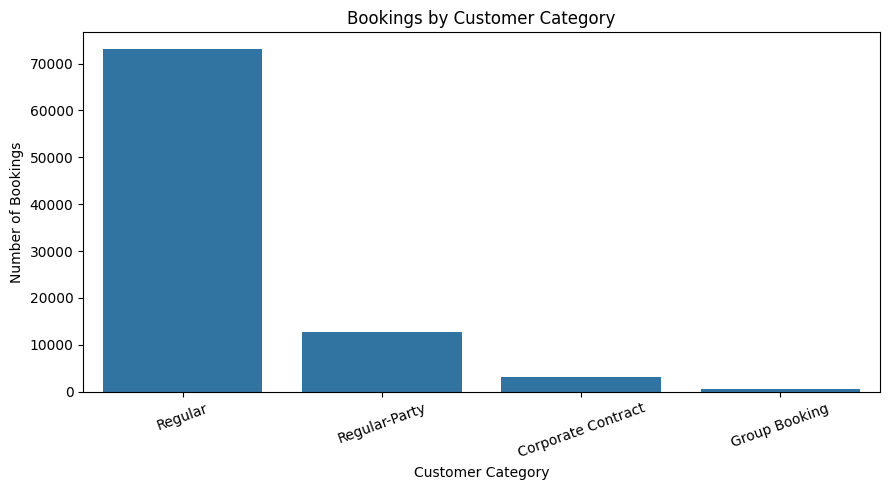

In [67]:
# Customer category distribution
customer_counts = clean_df["customer_category"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=customer_counts.index, y=customer_counts.values)
plt.title("Bookings by Customer Category")
plt.xlabel("Customer Category")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


,cancellation_rate_%
customer_category,
Regular,29.927407
Corporate Contract,16.853933
Regular-Party,15.663318
Group Booking,9.392265


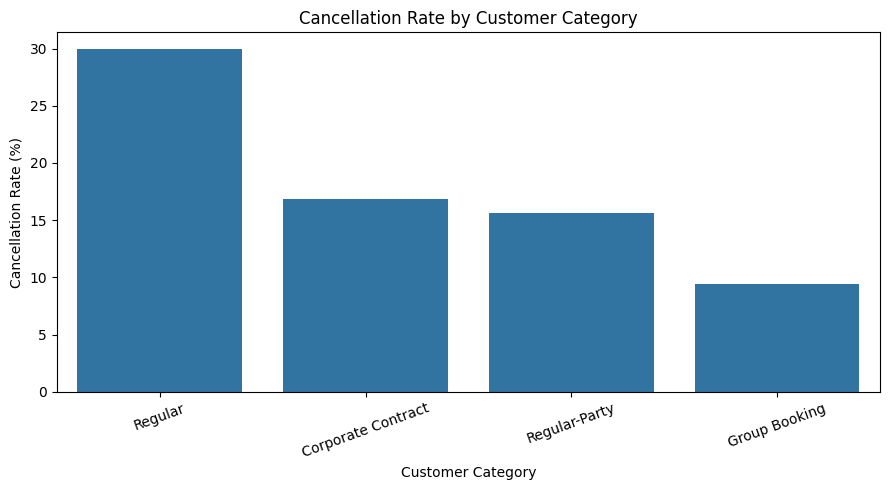

In [68]:
# Cancellation rate by customer category
cancel_by_customer = (
    clean_df.assign(
        cancelled=clean_df["reservation_status"].eq("Cancelled")
    )
    .groupby("customer_category")["cancelled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(cancel_by_customer.to_frame("cancellation_rate_%"))

plt.figure(figsize=(9, 5))
sns.barplot(
    x=cancel_by_customer.index,
    y=cancel_by_customer.values
)
plt.title("Cancellation Rate by Customer Category")
plt.xlabel("Customer Category")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [69]:
# Test whether customer category and cancellation are associated
contingency = pd.crosstab(
    clean_df["customer_category"],
    clean_df["reservation_status"].eq("Cancelled")
)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.6g}")

if p_value < 0.05:
    print("Conclusion: customer category and cancellation status are statistically associated.")
else:
    print("Conclusion: no statistically significant association was detected.")


Chi-square statistic: 1379.75
p-value: 7.28931e-299
Conclusion: customer category and cancellation status are statistically associated.


,bookings,avg_adr,cancellation_rate
arrival_month,,,
January,4787,73.20,21.29
February,6244,77.28,21.57
March,7682,83.04,23.42
April,8157,104.49,30.37
May,8664,111.80,28.95
June,8015,119.99,30.26
July,10299,134.35,31.38
August,11482,148.24,31.83
September,7005,112.74,25.02


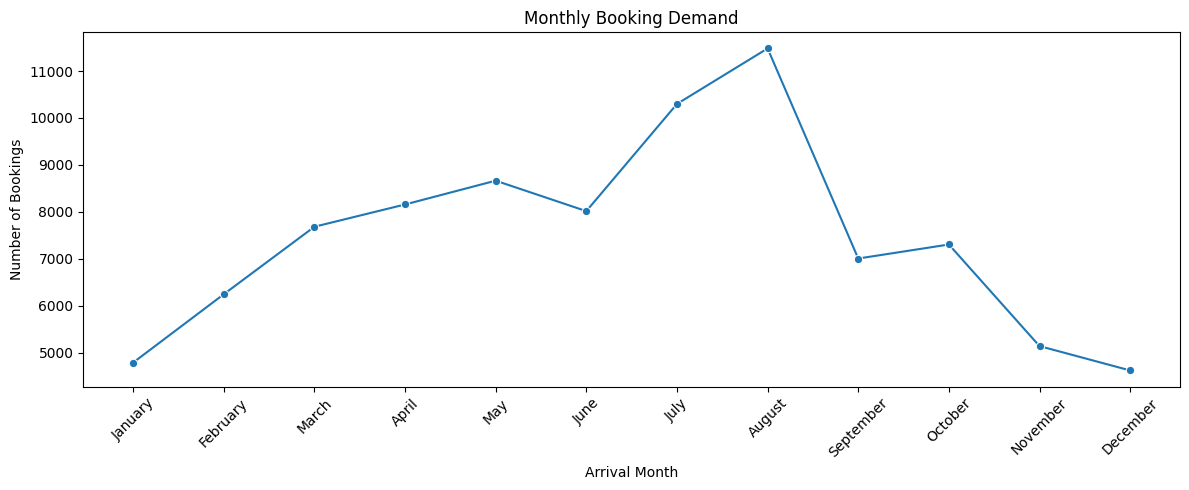

In [70]:
# Seasonal demand
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly = (
    clean_df.groupby("arrival_month")
    .agg(
        bookings=("arrival_month", "size"),
        avg_adr=("avg_daily_rate", "mean"),
        cancellation_rate=(
            "reservation_status",
            lambda x: (x == "Cancelled").mean() * 100
        )
    )
    .reindex(month_order)
)

display(monthly.round(2))

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly.index, y=monthly["bookings"], marker="o")
plt.title("Monthly Booking Demand")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


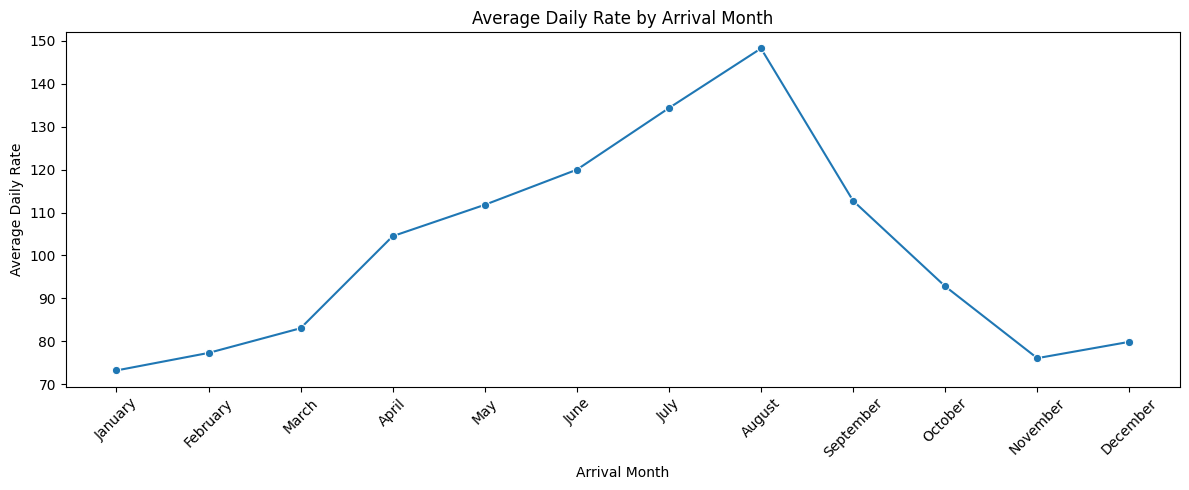

In [71]:
# Monthly pricing pattern
plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly.index, y=monthly["avg_adr"], marker="o")
plt.title("Average Daily Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Average Daily Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [72]:
# Booking channel behaviour
channel_summary = (
    clean_df.assign(
        cancelled=clean_df["reservation_status"].eq("Cancelled")
    )
    .groupby("booking_channel")
    .agg(
        bookings=("booking_channel", "size"),
        cancellation_rate=("cancelled", "mean"),
        avg_adr=("avg_daily_rate", "mean")
    )
)

channel_summary["cancellation_rate"] *= 100

display(channel_summary.sort_values("cancellation_rate", ascending=False).round(2))


,bookings,cancellation_rate,avg_adr
booking_channel,,,
Undefined,5,80.00,46.24
TA/TO,71061,30.96,108.50
GDS,182,18.13,123.07
Direct,12948,13.65,112.59
Corporate,5202,11.80,72.32


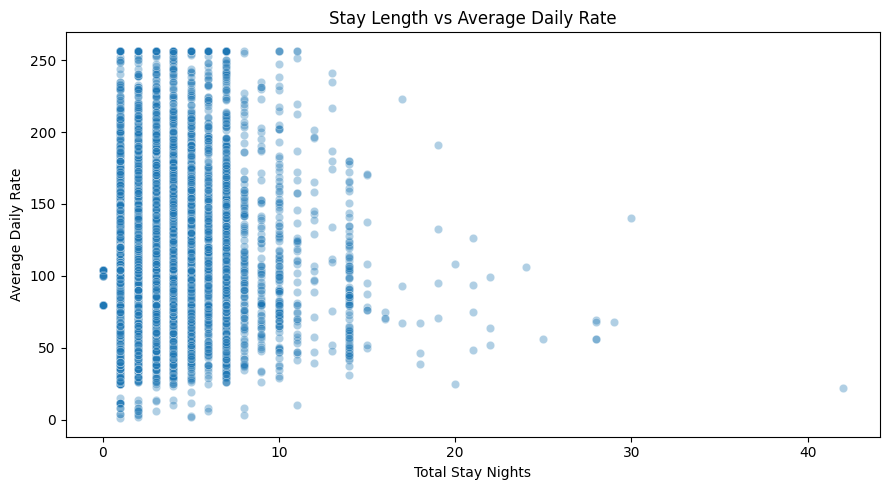

In [73]:
# Stay length and ADR relationship
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=clean_df.sample(min(10000, len(clean_df)), random_state=42),
    x="total_stay_nights",
    y="avg_daily_rate",
    alpha=0.35
)
plt.title("Stay Length vs Average Daily Rate")
plt.xlabel("Total Stay Nights")
plt.ylabel("Average Daily Rate")
plt.tight_layout()
plt.show()


## Investigation 5 — Investigate Business Relationships

We examine relationships between deposits, cancellations, demand, pricing, and booking channels.


,bookings,cancellation_rate,avg_adr
deposit_type,,,
Non Refund,1870,96.42,89.35
No Deposit,87417,25.85,107.42
Refundable,111,22.52,79.87


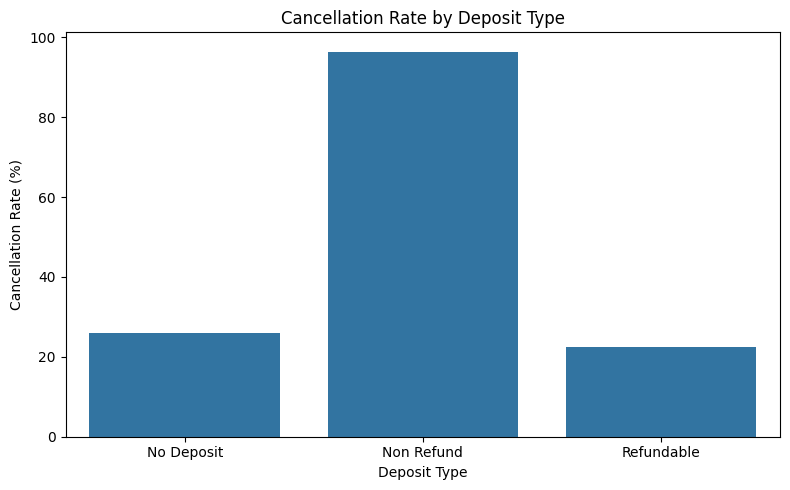

In [74]:
# Deposit type and cancellation
deposit_summary = (
    clean_df.assign(
        cancelled=clean_df["reservation_status"].eq("Cancelled")
    )
    .groupby("deposit_type")
    .agg(
        bookings=("deposit_type", "size"),
        cancellation_rate=("cancelled", "mean"),
        avg_adr=("avg_daily_rate", "mean")
    )
)

deposit_summary["cancellation_rate"] *= 100

display(deposit_summary.sort_values("cancellation_rate", ascending=False).round(2))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=deposit_summary.index,
    y=deposit_summary["cancellation_rate"]
)
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


In [75]:
# Demand and ADR relationship using chronologically ordered months
valid_months = monthly.dropna(subset=["bookings", "avg_adr"])

corr, corr_p = pearsonr(
    valid_months["bookings"],
    valid_months["avg_adr"]
)

print(f"Pearson correlation between monthly booking volume and ADR: {corr:.2f}")
print(f"p-value: {corr_p:.4f}")

if corr_p < 0.05:
    print("The relationship is statistically significant at the 5% level.")
else:
    print("The relationship is not statistically significant at the 5% level.")


Pearson correlation between monthly booking volume and ADR: 0.91
p-value: 0.0000
The relationship is statistically significant at the 5% level.


In [76]:
# Booking channel vs cancellation relationship
channel_status = pd.crosstab(
    clean_df["booking_channel"],
    clean_df["reservation_status"].eq("Cancelled")
)

chi2_channel, p_channel, _, _ = chi2_contingency(channel_status)

print(f"Chi-square statistic: {chi2_channel:.2f}")
print(f"p-value: {p_channel:.6g}")


Chi-square statistic: 2338.12
p-value: 0


## Investigation 6 — Discover Business Insights

The following calculations translate the observed cancellation behaviour into a more meaningful business measure.

The estimate below uses **ADR × stay nights** for cancelled bookings. It should be interpreted as **potential booking value at risk**, not guaranteed accounting revenue loss.


In [77]:
# Potential booking value at risk from cancellations
cancelled = clean_df[
    clean_df["reservation_status"] == "Cancelled"
].copy()

cancelled["booking_value_at_risk"] = (
    cancelled["avg_daily_rate"] *
    cancelled["total_stay_nights"]
)

total_booking_value = (
    clean_df["avg_daily_rate"] *
    clean_df["total_stay_nights"]
).sum()

value_at_risk = cancelled["booking_value_at_risk"].sum()

print(f"Cancelled bookings: {len(cancelled):,}")
print(f"Potential booking value at risk: {value_at_risk:,.2f}")
print(
    f"Share of total booking value represented by cancellations: "
    f"{value_at_risk / total_booking_value * 100:.2f}%"
)


Cancelled bookings: 24,421
Potential booking value at risk: 11,374,967.59
Share of total booking value represented by cancellations: 32.60%


In [78]:
# Identify high-risk customer and deposit segments
high_risk_customer = cancel_by_customer.idxmax()
high_risk_customer_rate = cancel_by_customer.max()

high_risk_deposit = deposit_summary["cancellation_rate"].idxmax()
high_risk_deposit_rate = deposit_summary["cancellation_rate"].max()

peak_month = monthly["bookings"].idxmax()
peak_month_bookings = monthly.loc[peak_month, "bookings"]

highest_price_month = monthly["avg_adr"].idxmax()
highest_month_adr = monthly.loc[highest_price_month, "avg_adr"]

print("Key evidence:")
print(
    f"- Highest customer-category cancellation rate: "
    f"{high_risk_customer} ({high_risk_customer_rate:.2f}%)"
)
print(
    f"- Highest deposit-type cancellation rate: "
    f"{high_risk_deposit} ({high_risk_deposit_rate:.2f}%)"
)
print(
    f"- Highest booking-demand month: "
    f"{peak_month} ({peak_month_bookings:,.0f} bookings)"
)
print(
    f"- Highest average ADR month: "
    f"{highest_price_month} ({highest_month_adr:.2f})"
)


Key evidence:
- Highest customer-category cancellation rate: Regular (29.93%)
- Highest deposit-type cancellation rate: Non Refund (96.42%)
- Highest booking-demand month: August (11,482 bookings)
- Highest average ADR month: August (148.24)


## Investigation 7 — Recommend Business Actions

Recommendations are linked directly to measurable findings rather than being generic suggestions.


In [79]:
# Scenario analysis: reducing cancellations
for reduction in [0.05, 0.10, 0.15]:
    recovered_value = value_at_risk * reduction
    print(
        f"{reduction:.0%} reduction in cancellations -> "
        f"potential booking value recovered: {recovered_value:,.2f}"
    )


5% reduction in cancellations -> potential booking value recovered: 568,748.38
10% reduction in cancellations -> potential booking value recovered: 1,137,496.76
15% reduction in cancellations -> potential booking value recovered: 1,706,245.14


In [80]:
# Compact decision table
recommendations = pd.DataFrame({
    "Business area": [
        "Cancellation management",
        "Deposit policy",
        "Seasonal planning",
        "Pricing",
        "Customer targeting"
    ],
    "Evidence": [
        f"Overall cancellation behaviour creates {value_at_risk:,.2f} in potential booking value at risk.",
        f"{high_risk_deposit} has the highest observed cancellation rate ({high_risk_deposit_rate:.2f}%).",
        f"{peak_month} has the highest booking volume ({peak_month_bookings:,.0f}).",
        f"{highest_price_month} has the highest average ADR ({highest_month_adr:.2f}).",
        f"{high_risk_customer} has the highest customer-category cancellation rate ({high_risk_customer_rate:.2f}%)."
    ],
    "Recommended action": [
        "Use targeted reminders and confirmation strategies for high-risk bookings.",
        "Review deposit requirements for segments with consistently high cancellation rates.",
        "Plan staffing and room inventory ahead of high-demand months.",
        "Use seasonal demand and ADR patterns to support dynamic pricing decisions.",
        "Design targeted retention or booking policies for high-risk customer segments."
    ]
})

display(recommendations)


,Business area,Evidence,Recommended action
0,Cancellation management,"Overall cancellation behaviour creates 11,374,...",Use targeted reminders and confirmation strate...
1,Deposit policy,Non Refund has the highest observed cancellati...,Review deposit requirements for segments with ...
2,Seasonal planning,"August has the highest booking volume (11,482).",Plan staffing and room inventory ahead of high...
3,Pricing,August has the highest average ADR (148.24).,Use seasonal demand and ADR patterns to suppor...
4,Customer targeting,Regular has the highest customer-category canc...,Design targeted retention or booking policies ...


## Final Data Quality Check

Before using the cleaned data for reporting, we verify that the major quality issues identified earlier have been addressed.


In [81]:
# Final validation
print("Final shape:", clean_df.shape)
print("Remaining exact duplicates:", clean_df.duplicated().sum())
print("Remaining invalid ADR values:", (clean_df["avg_daily_rate"] <= 0).sum())
print("Remaining invalid zero-adult/minor bookings:", (
    (clean_df["num_adults"] == 0) &
    (
        (clean_df["num_children"].fillna(0) > 0) |
        (clean_df["num_infants"].fillna(0) > 0)
    )
).sum())

print("\nFinal reservation status distribution:")
display(clean_df["reservation_status"].value_counts(dropna=False))

print("\nFinal missing-value summary:")
display(
    clean_df.isna().sum()
    .loc[lambda x: x > 0]
    .to_frame("missing_count")
)


Final shape: (89398, 37)
Remaining exact duplicates: 0
Remaining invalid ADR values: 0
Remaining invalid zero-adult/minor bookings: 0

Final reservation status distribution:


,count
reservation_status,
Checked-Out,63947
Cancelled,24421
No-Show,1030



Final missing-value summary:


,missing_count
travel_agent_id,15122
